# 4. Causal Inference: d-separation and estimands

`dowhy` 라이브러리를 설치하기 위해 `%pip -q install dowhy` 명령어를 실행하지만, 일반적으로 라이브러리 설치 코드는 실행 환경에 따라 필요할 때 주석을 해제하여 사용한다.

In [ ]:
#%pip -q install dowhy

In [1]:
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

시각화에 사용할 색상 코드를 리스트로 정의한다.

In [2]:
COLORS = [
    '#00B0F0',
    '#FF0000'
]

## 1\. DAG 시각화

`graphviz`를 사용하여 방향성 비순환 그래프(DAG)를 생성하고 시각화한다.

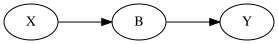

In [3]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'B', 'Y']
positions = ['1,0!', '2.5,0!', '4,0!']

edges = ['XB', 'BY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_06_d_sep_00')

graph

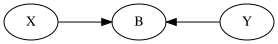

In [4]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'B', 'Y']
positions = ['1,0!', '2.5,0!', '4,0!']

edges = ['XB', 'YB']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_06_d_sep_01')

graph

'A', 'X', 'B', 'Y' 네 개의 노드를 사용하여 더 복잡한 DAG를 생성한다. 엣지는 'XB', 'YB', 'XA', 'AY'로, 이는 두 개의 경로, 즉 `X → A → Y` (연쇄)와 `X → B ← Y` (충돌)가 공존하는 구조를 나타낸다. 이 그래프는 `img/ch_06_d_sep_02` 파일로 저장된다.

이 구조에서 X와 Y의 인과적 효과를 식별하기 위해서는 d-separation을 고려해야 한다. `X → A → Y` 경로는 A를 조건으로 주면 차단되고, `X → B ← Y` 경로는 B를 조건으로 주지 않으면 차단된다.

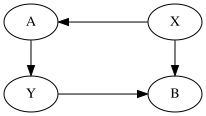

In [5]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'X', 'B', 'Y']
positions = ['1,1!', '3,1!', '3,0!', '1, 0!']

edges = ['XB', 'YB', 'XA', 'AY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_06_d_sep_02')

graph

'A', 'X', 'B', 'Y' 네 개의 노드를 사용하여 DAG를 생성한다. 엣지는 'XA', 'BA', 'BY'로 설정되어, 이는 `X → A ← B → Y` 구조를 나타낸다. 이 그래프는 `img/ch_06_d_sep_03` 파일로 저장된다.

이 DAG에서 X와 Y의 관계를 분석하면, `X → A ← B`는 충돌 경로이고 `B → Y`는 연쇄 경로의 일부이다. X와 Y 사이의 d-separation을 확인하려면 A와 B에 대한 조건부를 고려해야 한다. A를 조건으로 주면 X와 B 사이에 새로운 연관성이 생길 수 있다.

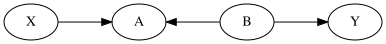

In [6]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'X', 'B', 'Y']
positions = ['1.5,0!', '0,0!', '3,0!', '4.5,0!']

edges = ['XA', 'BA', 'BY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_06_d_sep_03')

graph

'A', 'X', 'B', 'Y', 'C' 다섯 개의 노드를 사용하여 복잡한 DAG를 생성한다. 엣지는 'XA', 'XB', 'CB', 'CY', 'AY'로 설정되어, 다양한 경로가 복합적으로 얽혀있는 구조를 보여준다. 이 그래프는 `img/ch_06_d_sep_04` 파일로 저장된다.

d-separation을 통해 X와 Y의 독립성을 확인하기 위해서는 X와 Y를 잇는 모든 경로를 분석해야 한다. 예를 들어, `X → A → Y` 경로는 A를 조건으로 주면 차단된다. `X → B ← C → Y` 경로는 B를 조건으로 주지 않고, C를 조건으로 주면 열릴 수 있다. 이처럼 각 경로의 차단 여부를 분석하여 조건부 독립성을 판단한다.

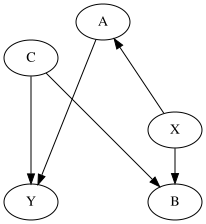

In [7]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['A', 'X', 'B', 'Y', 'C']
positions = ['2,2.5!', '3,1!', '3,0!', '1, 0!', '1,2!']

edges = ['XA', 'XB', 'CB', 'CY', 'AY']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(f'img/ch_06_d_sep_04')

graph

## 2\. Estimand

인과 추론에서 **Estimand**는 우리가 추정하고자 하는 인과적 양(causal quantity)의 통계적 정의이다. 예를 들어, 평균 처리 효과(Average Treatment Effect, ATE)인 $E[Y|do(X=1)] - E[Y|do(X=0)]$는 인과적 estimand이다. 반면, **Estimator**는 이 estimand를 데이터로부터 계산하는 구체적인 통계적 방법(예: 선형 회귀 계수, 평균값 계산)이며, 그 결과로 나오는 수치 값을 **Estimate**라고 한다.

출퇴근 시간 예시로 사용할 데이터 리스트 `t`를 정의한다.

In [8]:
# Commute example
# 출퇴근 예시
t = [22.1, 23.7, 25.2, 20.0, 21.8]

numpy의 `mean` 함수를 사용하여 리스트 `t`의 평균값을 계산한다. 여기서 `np.mean(t)`는 '평균 출퇴근 시간'이라는 estimand에 대한 estimator이며, 계산된 결과인 22.56은 estimate이다.

In [9]:
np.mean(t)

22.56

`graphviz`를 사용하여 'ICE'(아이스크림 판매량), 'TMP'(온도), 'ACC'(사고 발생률) 세 노드로 구성된 DAG를 생성한다. 엣지는 `TMP → ICE`와 `TMP → ACC`로, 이는 온도가 아이스크림 판매량과 사고 발생률 모두에 영향을 주는 공통 원인(common cause) 구조를 나타낸다. 이 그래프는 `img/ch_06_icecream` 파일로 저장된다.

이 구조에서 아이스크림 판매량(ICE)과 사고 발생률(ACC) 사이의 상관관계는 온도를 통해 발생하는 허위 상관(spurious correlation)일 수 있다. d-separation 규칙에 따르면, 공통 원인인 온도(TMP)를 조건으로 주면 ICE와 ACC 사이의 비인과적 경로는 차단된다.

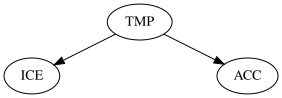

In [10]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['ICE', 'TMP', 'ACC']
positions = ['0,0!', '1.5,.75!', '3,0!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edge('TMP', 'ICE')
graph.edge('TMP', 'ACC')

graph.render(f'img/ch_06_icecream')

graph

'X', 'Y', 'A', 'B' 네 개의 노드를 사용하여 DAG를 생성한다. 엣지는 'XY', 'AX', 'AB', 'BY'로 설정되어 있다. 이 그래프는 `img/ch_06_equivalent_estimands_00` 파일로 저장된다.

이 구조에서 X에서 Y로의 인과적 효과를 추정하기 위한 estimand를 생각해볼 수 있다. A는 X의 원인이자 B의 원인이며, B는 Y의 원인이다. 만약 A가 관측되지 않은 변수라면, A는 X와 Y 사이의 비인과적 경로(`X ← A → B → Y`)를 여는 교란 변수(confounder) 역할을 할 수 있다.

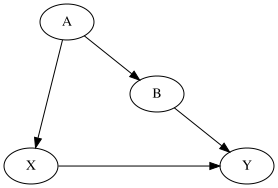

In [11]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'Y', 'A', 'B']
positions = ['0,0!', '3,0!', '.5,2!', '1.75,1!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(['XY', 'AX', 'AB', 'BY'])

graph.render(f'img/ch_06_equivalent_estimands_00')

graph

`graphviz` 객체의 `edge` 메서드에 대한 도움말을 출력한다. 이 메서드는 두 노드 사이에 엣지를 생성하는 데 사용되며, `tail_name`, `head_name`, `label` 등의 인자를 받는다.

In [12]:
?graph.edge

Signature:
graph.edge(
    tail_name: str,
    head_name: str,
    label: Optional[str] = None,
    _attributes=None,
    **attrs,
) -> None
Docstring:
Create an edge between two nodes.

Args:
    tail_name: Start node identifier
        (format: ``node[:port[:compass]]``).
    head_name: End node identifier
        (format: ``node[:port[:compass]]``).
    label: Caption to be displayed near the edge.
    attrs: Any additional edge attributes (must be strings).

Note:
    The ``tail_name`` and ``head_name`` strings are separated
    by (optional) colon(s) into ``node`` name, ``port`` name,
    and ``compass`` (e.g. ``sw``).
    See :ref:`details in the User Guide <node-ports-compass>`.

Attention:
    When rendering ``label``, backslash-escapes
    and strings of the form ``<...>`` have a special meaning.
    See the sections :ref:`backslash-escapes` and
    :ref:`quoting-and-html-like-labels` in the user guide for details.
File:      ~/anaconda3/envs/causal/lib/python3.10/site-package

앞서 생성한 `img/ch_06_equivalent_estimands_00` DAG에서 A 노드와 관련 엣지들을 점선으로 변경하여 시각화한다. 이는 A가 관측되지 않은(unobserved) 변수임을 나타내는 일반적인 표기법이다. 이 그래프는 `img/ch_06_equivalent_estimands_01` 파일로 저장된다.

A가 관측되지 않을 경우, `X ← A → B → Y` 경로는 열린 뒷문 경로(back-door path)가 되어 X와 Y의 순수한 인과 관계 추정을 방해한다. 이 경로를 차단하기 위해서는 A를 통제해야 하지만, 관측되지 않았으므로 불가능하다. 이런 경우 다른 식별 전략(identification strategy)이 필요하다.

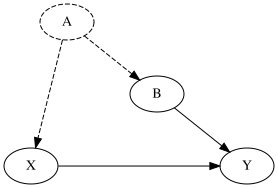

In [13]:
graph = graphviz.Digraph(format='png', engine='neato')


nodes = ['X', 'Y', 'A', 'B']
positions = ['0,0!', '3,0!', '.5,2!', '1.75,1!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]

# Overwrite style
# 스타일 덮어쓰기
graph.node('A', style='dashed')

graph.edges(['XY', 'BY'])
graph.edge('A', 'X', style='dashed')
graph.edge('A', 'B', style='dashed')

graph.render(f'img/ch_06_equivalent_estimands_01')

graph

## 3\. Front-door criterion

### 3.1 DAG

\*\*Front-door criterion(전면 기준)\*\*은 관측되지 않은 교란 변수가 있을 때, 매개 변수(mediator)를 이용하여 인과 효과를 식별하는 방법이다. 이 기준이 성립하기 위해서는 특정 매개 변수 Z가 다음 세 가지 조건을 만족해야 한다.

1.  Z는 X에서 Y로 가는 모든 직접적인 인과 경로를 차단한다.
2.  X에서 Z로 가는 뒷문 경로는 없다.
3.  X는 Z에서 Y로 가는 모든 뒷문 경로를 차단한다.

`dowhy` 라이브러리에서 `CausalModel` 클래스를 가져온다. 이 클래스는 인과 모델을 정의하고 분석하는 데 사용된다.

In [14]:
from dowhy.causal_model import CausalModel

'GPS', 'Memory', 'Motivation' 세 노드로 구성된 DAG를 생성한다. 여기서 'Motivation'은 관측되지 않은 변수로 점선으로 표시된다. 엣지는 `Motivation → GPS`, `Motivation → Memory`, `GPS → Memory`로 설정되어, 'Motivation'이 'GPS' 사용과 'Memory' 사이의 공통 원인(교란 변수)임을 나타낸다. 이 그래프는 `img/ch_06_gps_01` 파일로 저장된다.

이 구조에서 'Motivation'을 관측할 수 없으므로, GPS 사용이 기억력에 미치는 순수한 인과 효과를 후문 기준(back-door criterion)을 통해 식별할 수 없다.

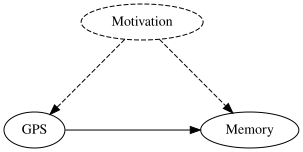

In [15]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['GPS', 'Memory', 'Motivation']
positions = ['0,0!', '3,0!', '1.5,1.5!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]

# Overwrite style
# 스타일 덮어쓰기
graph.node('Motivation', style='dashed')

graph.edge('Motivation', 'GPS', style='dashed')
graph.edge('Motivation', 'Memory', style='dashed')
graph.edge('GPS', 'Memory')

graph.render(f'img/ch_06_gps_01')

graph

'GPS', 'Hippocampal vol.'(해마 부피), 'Memory', 'Motivation' 네 개의 노드를 사용하여 DAG를 생성한다. 'Motivation'은 여전히 관측되지 않은 교란 변수이다. 엣지 구조는 `GPS → Hippocampal vol. → Memory`이며, `Motivation`이 `GPS`와 `Memory` 모두에 영향을 준다. 이 그래프는 `img/ch_06_gps_02` 파일로 저장된다.

이 구조에서 'Hippocampal vol.'은 GPS 사용과 기억력 사이의 매개 변수(mediator)이다. 이 매개 변수가 전면 기준(front-door criterion)의 조건을 만족하는지 확인할 수 있다.

1.  'Hippocampal vol.'은 'GPS'에서 'Memory'로 가는 유일한 인과 경로이다.
2.  'GPS'에서 'Hippocampal vol.'로 가는 뒷문 경로(`GPS ← Motivation → Memory → Hippocampal vol.`는 충돌 변수인 Memory에서 막힘)는 없다.
3.  'GPS'는 'Hippocampal vol.'에서 'Memory'로 가는 뒷문 경로(`Hippocampal vol. ← GPS ← Motivation → Memory`)를 차단한다.
    따라서, 'Hippocampal vol.'을 이용해 전면 조정을 수행할 수 있다.

<!-- end list -->

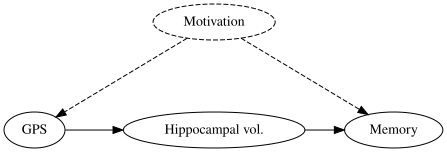

In [16]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['GPS', 'Hippocampal vol.', 'Memory', 'Motivation']
positions = ['0,0!', '2.5,0!', '5,0!', '2.5,1.5!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]

# Overwrite style
# 스타일 덮어쓰기
graph.node('Motivation', style='dashed')

graph.edge('Motivation', 'GPS', style='dashed')
graph.edge('Motivation', 'Memory', style='dashed')
graph.edge('GPS', 'Hippocampal vol.')
graph.edge('Hippocampal vol.', 'Memory')

graph.render(f'img/ch_06_gps_02')

graph

'X', 'Z', 'Y', 'U' 네 개의 노드로 일반화된 전면 기준(front-door criterion) DAG를 생성한다. 'U'는 관측되지 않은 교란 변수이다. 엣지 구조는 `X → Z → Y`이며, `U`는 `X`와 `Y` 모두에 영향을 준다. 이 그래프는 `img/ch_06_gps_03` 파일로 저장된다.

이 DAG는 전면 기준의 핵심 구조를 보여준다. X(처리)와 Y(결과) 사이에 관측되지 않은 교란 변수 U가 있지만, 매개 변수 Z가 X에서 Y로 가는 모든 인과적 흐름을 매개하고, X와 Z, 그리고 Z와 Y 사이에는 교란 요인이 없다(X에 의해 차단됨). 따라서, Z를 이용해 X가 Y에 미치는 인과 효과를 추정할 수 있다.

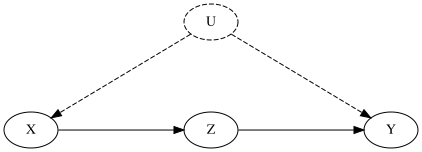

In [17]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'Z', 'Y', 'U']
positions = ['0,0!', '2.5,0!', '5,0!', '2.5,1.5!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]

# Overwrite style
# 스타일 덮어쓰기
graph.node('U', style='dashed')

graph.edge('U', 'X', style='dashed')
graph.edge('U', 'Y', style='dashed')
graph.edge('X', 'Z')
graph.edge('Z', 'Y')

graph.render(f'img/ch_06_gps_03')

graph

### 3.2 실전에서의 전면 기준

선형 회귀 모델을 사용하기 위해 `sklearn.linear_model`에서 `LinearRegression` 클래스를 가져온다.

In [18]:
from sklearn.linear_model import LinearRegression

GPS와 기억력의 관계를 모델링하는 구조적 인과 모델(Structural Causal Model, SCM) 클래스 `GPSMemorySCM`을 정의한다.

  - `__init__`: SCM의 외생 변수(exogenous variables)인 `u_x`, `u_y`, `u_z`, `u`의 확률 분포를 정의한다. `u`는 GPS 사용과 기억력에 모두 영향을 주는 관측되지 않은 교란 변수(열정 등)를 나타낸다.
  - `sample`: 정의된 인과 관계식에 따라 관측 데이터를 생성한다. 예를 들어, `hippocampus = -0.6*gps + 0.25*u_z`와 같이 각 변수가 다른 변수들에 의해 어떻게 결정되는지 정의한다.
  - `intervene`: 특정 처리(treatment) 값에 대한 중재(intervention)를 시뮬레이션한다. 이는 `do-operator`를 구현하는 것으로, `gps` 변수 값을 강제로 설정하여 그에 따른 결과를 관찰한다.

<!-- end list -->

In [19]:
# First, we'll build a structural causal model (SCM)
# 먼저, 구조적 인과 모델(SCM)을 구축한다
class GPSMemorySCM:

    def __init__(self, random_seed=None):
        self.random_seed = random_seed
        self.u_x = stats.truncnorm(0, np.infty, scale=5)
        self.u_y = stats.norm(scale=2)
        self.u_z = stats.norm(scale=2)
        self.u = stats.truncnorm(0, np.infty, scale=4)

    def sample(self, sample_size=100, treatment_value=None):
        """Samples from the SCM"""
        """SCM에서 샘플링한다"""
        if self.random_seed:
            np.random.seed(self.random_seed)

        u_x = self.u_x.rvs(sample_size)
        u_y = self.u_y.rvs(sample_size)
        u_z = self.u_z.rvs(sample_size)
        u = self.u.rvs(sample_size)

        if treatment_value:
            gps = np.array([treatment_value]*sample_size)
        else:
            gps = u_x + 0.7*u

        hippocampus = -0.6*gps + 0.25*u_z
        memory = 0.7*hippocampus + 0.25*u

        return gps, hippocampus, memory

    def intervene(self, treatment_value, sample_size=100):
        """Intervenes on the SCM"""
        """SCM에 중재를 가한다"""
        return self.sample(treatment_value=treatment_value, sample_size=sample_size)

정의된 `GPSMemorySCM`을 사용하여 데이터를 생성한다.

  - `scm.sample(600)`를 통해 600개의 관측 데이터를 생성한다.
  - `scm.intervene()`를 사용하여 GPS 사용량(treatment)을 1부터 20까지 변화시키며 실험(중재) 데이터를 생성한다. 이는 인과 효과를 직접 확인하기 위한 이상적인 실험 상황을 시뮬레이션하는 것이다.

<!-- end list -->

In [20]:
# Instantiate the SCM
# SCM 인스턴스화
scm = GPSMemorySCM()

# Generate observational data
# 관측 데이터 생성
gps_obs, hippocampus_obs, memory_obs = scm.sample(600)

# Run an experiment
# 실험 실행
treatments = []
experiment_results = []

# Sample over various treatments
# 다양한 처리에 대해 샘플링
for treatment in np.arange(1, 21):
    gps_hours, hippocampus, memory = scm.intervene(treatment_value=treatment, sample_size=30)
    experiment_results.append(memory)
    treatments.append(gps_hours)

`matplotlib`를 사용하여 관측 데이터와 실험(중재) 데이터를 시각화한다.

  - 왼쪽 플롯은 관측 데이터(`gps_obs`, `memory_obs`)의 산점도로, GPS 사용량과 공간 기억력 변화 사이에 양의 상관관계가 있는 것처럼 보인다. 이는 교란 변수 '열정(U)'의 영향 때문이다.
  - 오른쪽 플롯은 중재 데이터(`treatments`, `experiment_results`)의 산점도로, GPS 사용량이 증가할수록 공간 기억력이 감소하는 실제 인과 관계(음의 관계)를 보여준다.

<!-- end list -->

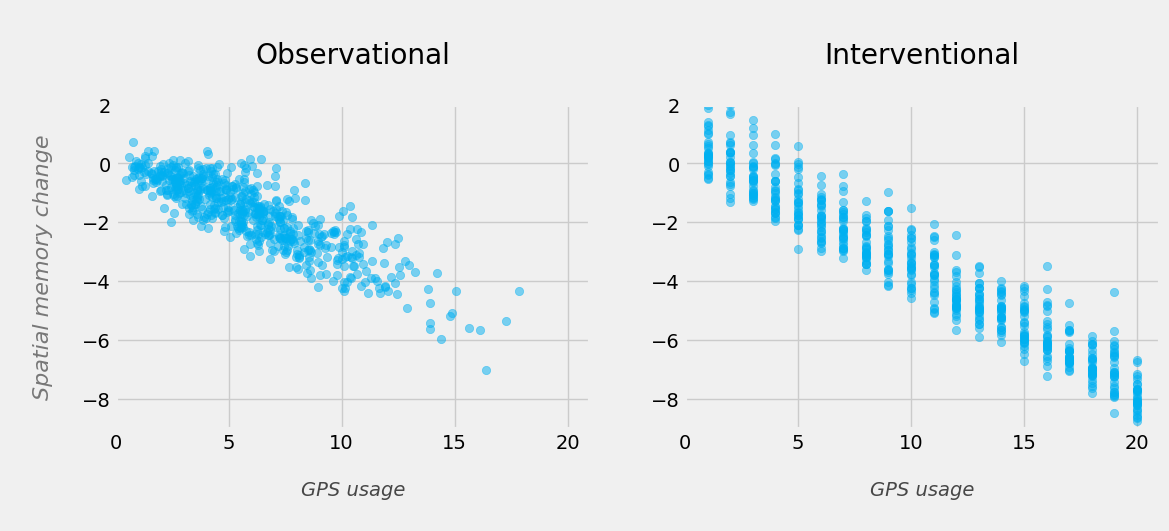

In [21]:
# Plot observational data
# 관측 데이터 시각화
plt.figure(figsize=(12, 4))

# Observational
# 관측
plt.subplot(121)
plt.scatter(gps_obs, memory_obs, alpha=.5, color=COLORS[0])
plt.xlim(0, 21)
plt.ylim(-9, 2)

plt.title('\nObservational\n')
plt.xlabel('\nGPS usage', alpha=.7, fontsize=14, style='italic')
plt.ylabel('\nSpatial memory change\n', alpha=.5, fontsize=16, style='italic')


# Interventional
# 중재
plt.subplot(122)

plt.scatter(treatments, experiment_results, alpha=.5, color=COLORS[0])
plt.xlim(0, 21)
plt.ylim(-9, 2)

plt.title('\nInterventional\n')
plt.xlabel('\nGPS usage\n', alpha=.7, fontsize=14, style='italic')

plt.show()

## 4\. 모델

### 4.1 순진한 모델 1

관측 데이터만을 사용하여 GPS 사용량(`gps_obs`)이 기억력(`memory_obs`)에 미치는 영향을 추정하는 순진한(naive) 선형 회귀 모델을 학습시킨다. 이 모델은 교란 변수 '열정(U)'의 존재를 무시하기 때문에 편향된 결과를 낳을 수 있다.

In [ ]:
lr_naive = LinearRegression()
lr_naive.fit(
    X=gps_obs.reshape(-1, 1),
    y=memory_obs
)

#### 실행 결과

```
LinearRegression()
```

### 4.2 실험 모델

실험(중재) 데이터를 사용하여 GPS 사용량(`treatments_unpack`)이 기억력(`results_unpack`)에 미치는 영향을 추정하는 선형 회귀 모델을 학습시킨다. 이 모델은 중재를 통해 교란 변수의 영향을 제거했기 때문에 참된 인과 효과에 가까운 추정치를 제공한다.

In [ ]:
treatments_unpack = np.array(treatments).flatten()
results_unpack = np.array(experiment_results).flatten()

lr_experiment = LinearRegression()
lr_experiment.fit(
    X=treatments_unpack.reshape(-1, 1),
    y=results_unpack
)

#### 실행 결과

```
LinearRegression()
```

학습된 두 모델(순진한 모델, 실험 모델)을 사용하여 테스트 데이터(`X_test`)에 대한 예측값을 생성한다.

In [24]:
X_test = np.arange(1, 21).reshape(-1, 1)

preds_naive = lr_naive.predict(X_test)
preds_experiment = lr_experiment.predict(X_test)

실험 데이터의 산점도 위에 순진한 모델과 실험 모델의 회귀선을 함께 그려 비교한다.

  - **Naive(순진한 모델)** 라인은 양의 기울기를 보여주어 GPS 사용이 기억력에 긍정적인 영향을 미치는 것처럼 잘못된 결론을 내린다.
  - **Experimental(실험 모델)** 라인은 음의 기울기를 보여주어 실제 인과 관계인 'GPS 사용이 기억력을 감소시킨다'는 것을 정확히 보여준다.

<!-- end list -->

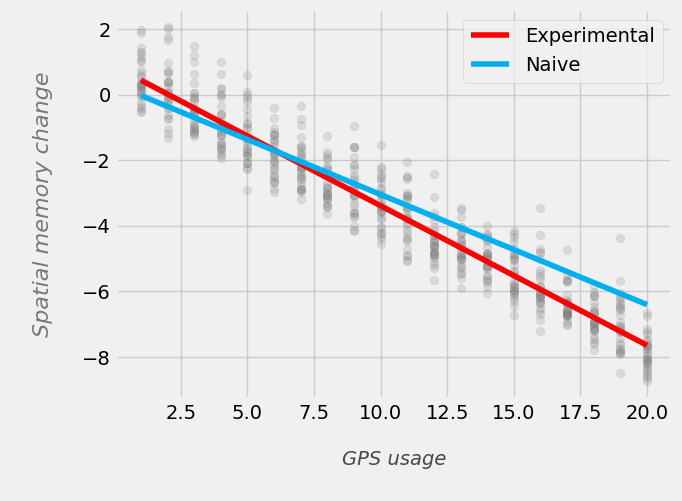

In [25]:
plt.scatter(treatments, experiment_results, alpha=.2, color='gray')
plt.plot(X_test, preds_experiment, label='Experimental', color=COLORS[1])
plt.plot(X_test, preds_naive, label='Naive', color=COLORS[0])

plt.xlabel('\nGPS usage\n', alpha=.7, fontsize=14, style='italic')
plt.ylabel('\nSpatial memory change\n', alpha=.5, fontsize=16, style='italic')

plt.legend()
plt.show()

두 모델에서 추정된 GPS 사용량의 회귀 계수(인과 효과 추정치)를 출력한다.

  - **Naive model(순진한 모델)**: 양수 값으로, 잘못된 양의 인과 효과를 나타낸다.
  - **Experimental model(실험 모델)**: 음수 값으로, 실제 음의 인과 효과를 보여준다.

<!-- end list -->

In [26]:
# Get coefficients
# 계수 얻기
print(f'Naive model:\n{lr_naive.coef_[0]}\n')
print(f'Experiemntal model:\n{lr_experiment.coef_[0]}')

Naive model:
-0.33577906051049333

Experiemntal model:
-0.42565721987282673


## 4\. 인과 추론을 위한 선형 연결 다리

전면 기준(Front-door criterion)을 선형 회귀 모델을 통해 적용하여 인과 효과를 추정한다. 전면 조정 공식은 다음과 같이 두 단계의 회귀로 구현될 수 있다:

1.  **$E(Z|X)$ 모델링**: 처리(X)가 매개 변수(Z)에 미치는 영향을 회귀 분석으로 추정한다. (`lr_zx` 모델)
2.  **$E(Y|X, Z)$ 모델링**: 처리(X)와 매개 변수(Z)가 결과(Y)에 미치는 영향을 다중 회귀 분석으로 추정한다. (`lr_yxz` 모델)

이 두 모델에서 얻은 계수를 곱하면($\\beta\_{ZX} \\times \\beta\_{YZ \\cdot X}$) X가 Z를 통해 Y에 미치는 인과 효과를 추정할 수 있다.

관측 데이터를 사용하여 위 두 단계의 선형 회귀 모델을 학습시킨다.

  - `lr_zx`: GPS(`gps_obs`)가 해마 부피(`hippocampus_obs`)에 미치는 영향을 모델링한다.
  - `lr_yxz`: GPS(`gps_obs`)와 해마 부피(`hippocampus_obs`)가 기억력(`memory_obs`)에 미치는 영향을 모델링한다.

두 모델의 계수를 곱하여 GPS 사용이 기억력에 미치는 인과 효과를 계산한다. 이 값은 실험 모델에서 얻은 인과 효과 추정치와 매우 유사해야 한다.

In [27]:
# Model E(Z|X)
# E(Z|X) 모델
lr_zx = LinearRegression()
lr_zx.fit(
    X=gps_obs.reshape(-1, 1),
    y=hippocampus_obs
)

# Model E(Y|X, Z)E(X)
# E(Y|X, Z)E(X) 모델
lr_yxz = LinearRegression()
lr_yxz.fit(
    X=np.array([gps_obs,hippocampus_obs]).T,
    y=memory_obs
)

# Compute the expected causal effect
# 기대 인과 효과 계산
lr_zx.coef_[0] * lr_yxz.coef_[1]

'Z', 'X', 'Y', 'U' 네 개의 노드로 도구 변수(Instrumental Variable, IV) 구조를 나타내는 DAG를 생성한다. 'U'는 관측되지 않은 교란 변수이다. 엣지 구조는 `Z → X → Y`이며, `U`는 `X`와 `Y` 모두에 영향을 준다. 이 그래프는 `img/ch_06_instrumental_00` 파일로 저장된다.

\*\*도구 변수(IV)\*\*는 다음 세 가지 조건을 만족하는 변수 Z이다:

1.  Z는 처리 변수 X와 연관되어 있다 (관련성).
2.  Z는 관측되지 않은 교란 변수 U와 독립이다 (독립성).
3.  Z는 X를 통하지 않고는 결과 Y에 영향을 주지 않는다 (제외 제한).

이러한 Z를 사용하면, U의 교란 효과가 있더라도 X가 Y에 미치는 인과 효과를 추정할 수 있다.

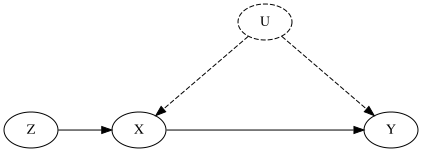

In [28]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['Z', 'X', 'Y', 'U']
positions = ['0,0!', '1.5,0!', '5,0!', '3.25,1.5!']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]

# Overwrite style
# 스타일 덮어쓰기
graph.node('U', style='dashed')

graph.edge('U', 'X', style='dashed')
graph.edge('U', 'Y', style='dashed')
graph.edge('Z', 'X')
graph.edge('X', 'Y')

graph.render(f'img/ch_06_instrumental_00')

graph

도구 변수(IV) 설정을 모델링하는 구조적 인과 모델(SCM) 클래스 `InstrumentalSCM`을 정의한다.

  - `u_xy`는 X와 Y 모두에 영향을 주는 관측되지 않은 교란 변수를 나타낸다.
  - `u_z`는 도구 변수 Z에만 영향을 주는 외생 변수이다.
  - `sample` 메서드는 정의된 관계식(`x = 0.7*z + 0.2*u_xy`, `y = 0.8*x + 0.1*u_xy`)에 따라 데이터를 생성한다.

<!-- end list -->

In [29]:
# First, we'll build a structural causal model (SCM)
# 먼저, 구조적 인과 모델(SCM)을 구축한다
class InsrumentalSCM:

    def __init__(self, random_seed=None):
        self.random_seed = random_seed
        self.u_xy = stats.norm()
        self.u_z = stats.norm()

    def sample(self, sample_size=100):
        """Samples from the SCM"""
        """SCM에서 샘플링한다"""
        if self.random_seed:
            np.random.seed(self.random_seed)

        u_xy = self.u_xy.rvs(sample_size)
        u_z = self.u_z.rvs(sample_size)

        z = u_z
        x = 0.7*z + 0.2*u_xy
        y = 0.8*x + 0.1*u_xy

        return z, x, y

정의된 `InstrumentalSCM`을 사용하여 1000개의 샘플 데이터를 생성한다.

In [30]:
# Instantiate the SCM and sample
# SCM 인스턴스화 및 샘플링
instr_scm = InsrumentalSCM()
z, x, y = instr_scm.sample(1000)

도구 변수 추정법(IV a.k.a Wald estimator)을 선형 회귀를 통해 구현한다. IV 추정량은 (Z가 Y에 미치는 효과) / (Z가 X에 미치는 효과)로 계산된다. 이는 두 단계의 회귀 분석으로 구현할 수 있다.

1.  `lr_yz`: Z가 Y에 미치는 영향을 모델링한다.
2.  `lr_xz`: Z가 X에 미치는 영향을 모델링한다.

<!-- end list -->

In [ ]:
# Fit regression 1
# 회귀 1 학습
lr_yz = LinearRegression()
lr_yz.fit(X=z.reshape(-1, 1), y=y)

# Fit regression 2
# 회귀 2 학습
lr_xz = LinearRegression()
lr_xz.fit(X=z.reshape(-1, 1), y=x)

#### 실행 결과

```
LinearRegression()
```

두 회귀 모델의 계수를 나누어 X가 Y에 미치는 인과 효과를 계산한다. 이 값은 SCM에서 설정한 실제 인과 계수인 0.8에 가까워야 한다.

In [32]:
# Compute the causal effect
# 인과 효과 계산
causal_effect = lr_yz.coef_[0] / lr_xz.coef_[0]
causal_effect

도구 변수 추정법으로 계산한 인과 효과와 실제 인과 효과를 비교하여 검증한다. 임의의 `random_z` 값에 대해, Z에서 Y로 가는 총 효과는 두 경로(`random_z * 0.7 * 0.8`와 `random_z * 0.7 * causal_effect`)를 통해 계산될 수 있으며, 두 결과값이 유사함을 보여준다.

In [33]:
# Sanity check
# 온전성 확인
random_z = np.random.randn()

random_z * .7 * .8, random_z * .7 * causal_effect

#### 실행 결과

```
(-0.33269222247054686, -0.3337039013717354)
```

`graphviz`를 사용하여 'X', 'W', 'Y' 세 노드로 구성된 후문 기준(Back-door criterion)을 설명하기 위한 DAG를 생성한다. 엣지는 'XY', 'WY', 'WX'로 설정되어 'W'가 'X'와 'Y'의 공통 원인(교란 변수)임을 나타낸다. 이 그래프는 `img/BCKDR.png` 파일로 렌더링하도록 지정되어 있다(실제 파일 생성은 실행 환경에 따라 다름).

후문 기준은 X가 Y에 미치는 인과 효과를 식별하기 위해 통제해야 할 변수 집합을 찾는 방법이다. 이 DAG에서 W는 X와 Y 사이의 비인과적 경로(`X ← W → Y`)를 열기 때문에, W를 통제(조건부)하면 이 경로를 차단하여 X의 순수한 인과 효과를 추정할 수 있다.

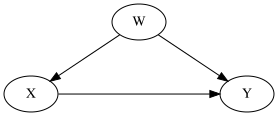

In [34]:
graph = graphviz.Digraph(format='png', engine='neato')

nodes = ['X', 'W', 'Y']
positions = ['1,0!', '2.5,1!', '4,0!']

edges = ['XY', 'WY', 'WX']

[graph.node(n, pos=pos) for n, pos in zip(nodes, positions)]
graph.edges(edges)

graph.render(r'img/BCKDR.png')

graph